also optional but also cool


Load best trained model
Create interactive widget
Upload custom image → predict letter
Show prediction confidence
Live demo for presentation

In [1]:
# imports 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras

# Load best model (update filename if needed)
model = keras.models.load_model('../results/models/custom_cnn_model.h5')

letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 
           'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R',
           'S', 'T', 'U', 'V', 'W', 'X', 'Y']

In [5]:
#prediction function
def predict_sign(image):
    """
    Predict ASL letter from image
    
    Args:
        image: 28x28 numpy array (grayscale)
    
    Returns:
        predicted_letter, confidence, all_probabilities
    """
    #ensure correct shape
    if image.shape != (28, 28):
        raise ValueError("Image must be 28x28")
    
    #preprocess
    img = image.reshape(1, 28, 28, 1) / 255.0
    
    #predict
    predictions = model.predict(img, verbose=0)[0]
    
    #get top prediction
    pred_idx = np.argmax(predictions)
    label_to_letter = {
    0:'A', 1:'B', 2:'C', 3:'D', 4:'E', 5:'F', 6:'G', 7:'H',
    8:'I', 10:'K', 11:'L', 12:'M', 13:'N', 14:'O', 15:'P',
    16:'Q', 17:'R', 18:'S', 19:'T', 20:'U', 21:'V', 22:'W',
    23:'X', 24:'Y'
}
    pred_letter = label_to_letter[pred_idx]
    confidence = predictions[pred_idx]
    
    return pred_letter, confidence, predictions


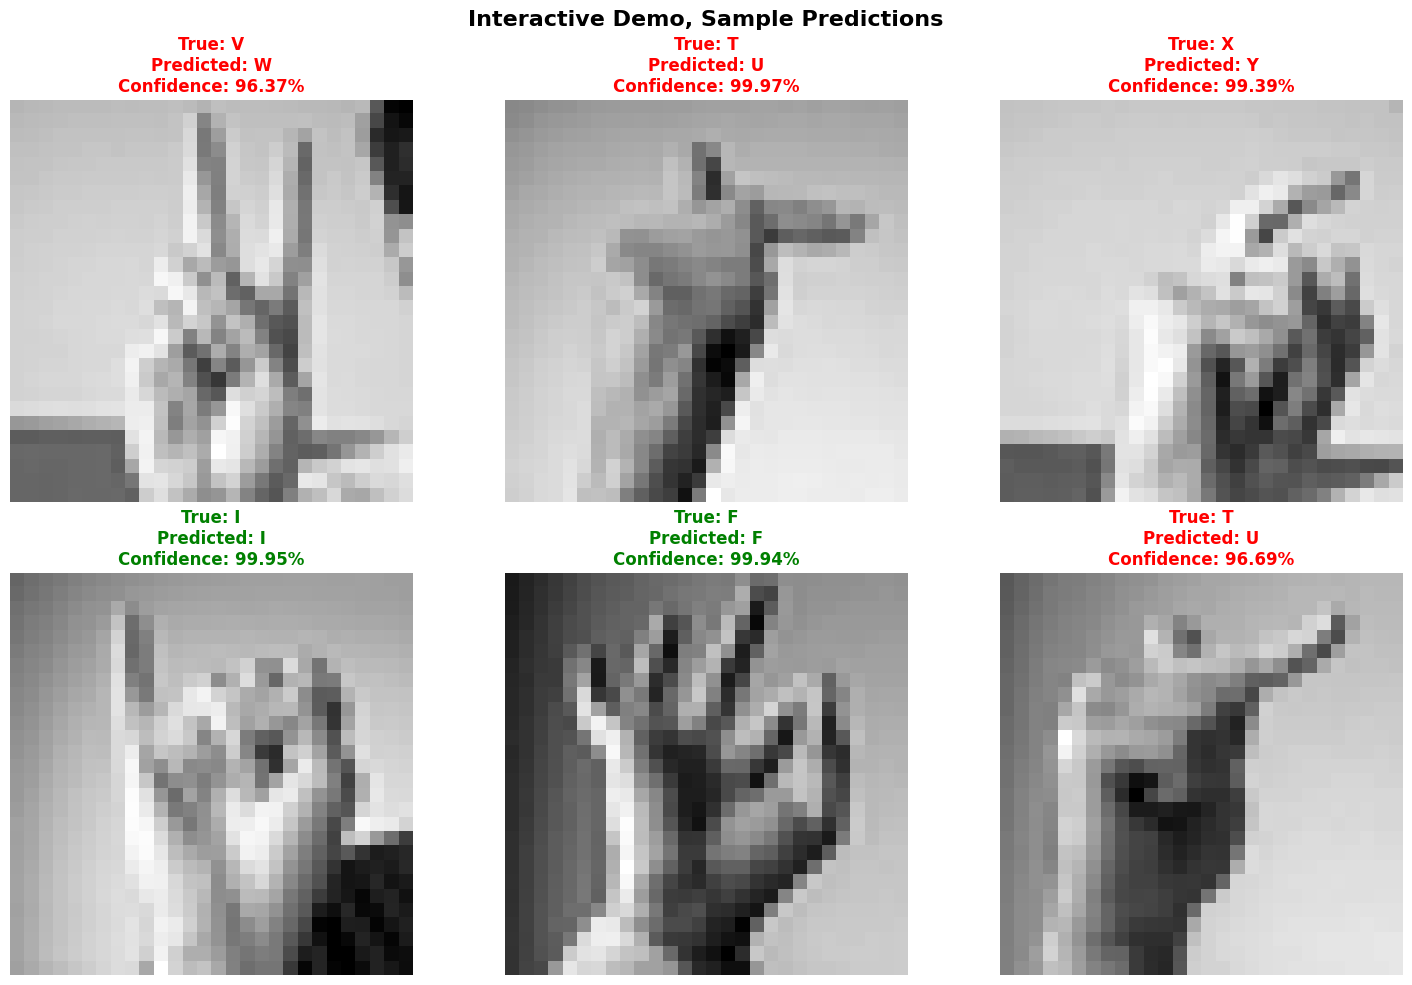

In [4]:
#demo using test image 
#load test data
test_data = pd.read_csv('../data/sign_mnist_test.csv')
X_test = test_data.drop('label', axis=1).values.reshape(-1, 28, 28)
y_test = test_data['label'].values

#select random test images
num_samples = 6
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, img_idx in enumerate(random_indices):
    image = X_test[img_idx]
    label_to_letter = {
    0:'A', 1:'B', 2:'C', 3:'D', 4:'E', 5:'F', 6:'G', 7:'H',
    8:'I', 10:'K', 11:'L', 12:'M', 13:'N', 14:'O', 15:'P',
    16:'Q', 17:'R', 18:'S', 19:'T', 20:'U', 21:'V', 22:'W',
    23:'X', 24:'Y'
}
    true_label = label_to_letter[y_test[img_idx]]
    
    #predict
    pred_letter, confidence, all_probs = predict_sign(image)
    
    #plot
    axes[idx].imshow(image, cmap='gray')
    color = 'green' if pred_letter == true_label else 'red'
    axes[idx].set_title(
        f'True: {true_label}\nPredicted: {pred_letter}\nConfidence: {confidence:.2%}',
        fontweight='bold', color=color, fontsize=12
    )
    axes[idx].axis('off')

plt.suptitle('Interactive Demo, Sample Predictions', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

### results 

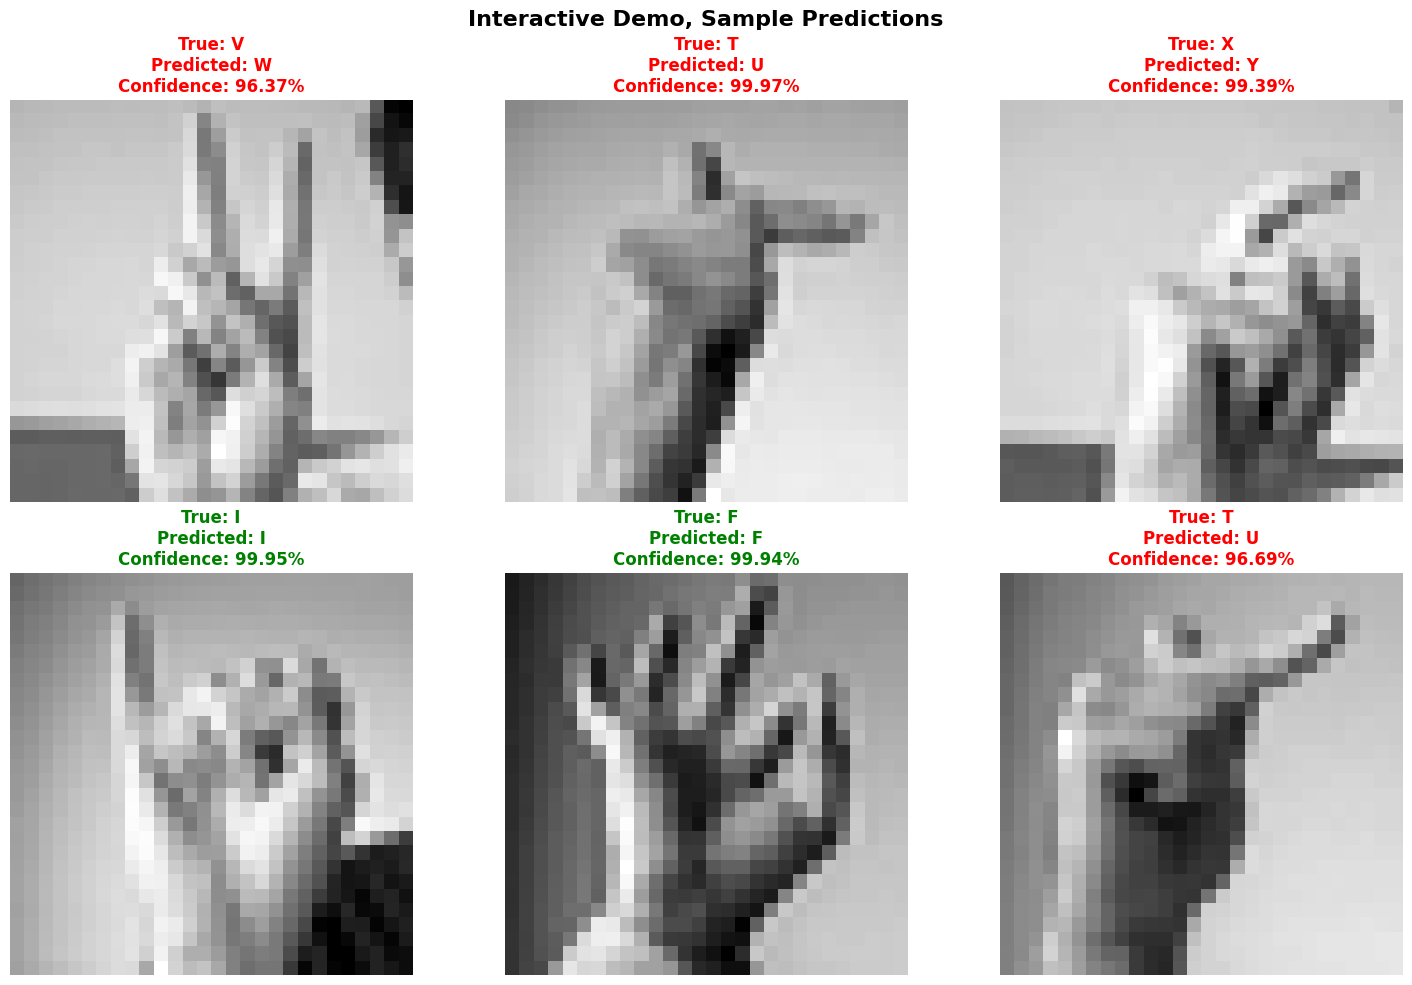

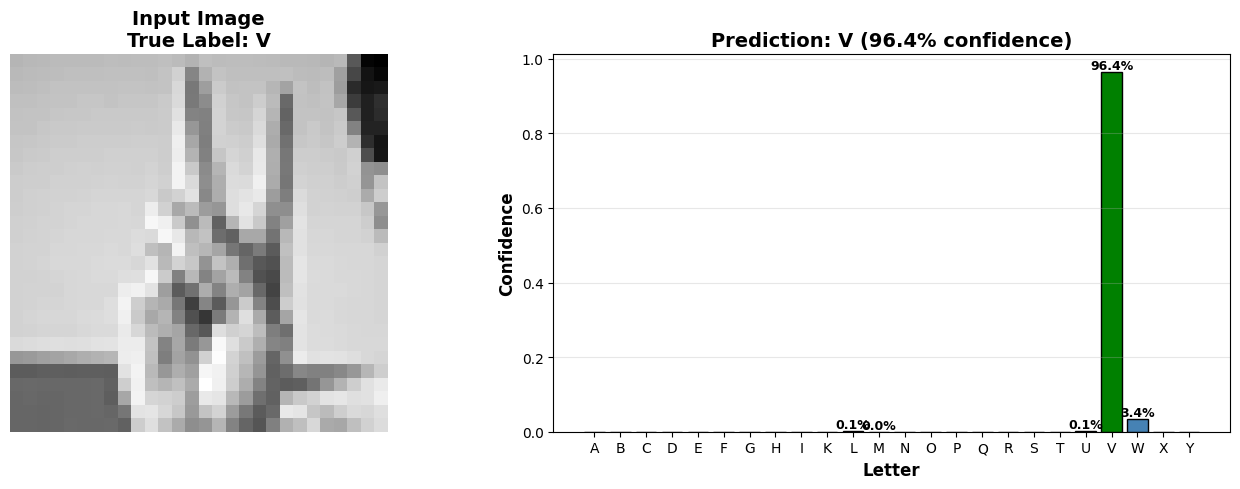


Prediction: V
Confidence: 96.37%

Top 5 predictions:
   V: 96.37%
   W: 3.37%
   L: 0.10%
   U: 0.08%
   M: 0.04%


In [8]:
#confidence visuals

#define label mapping
label_to_letter = {
    0:'A', 1:'B', 2:'C', 3:'D', 4:'E', 5:'F', 6:'G', 7:'H',
    8:'I', 10:'K', 11:'L', 12:'M', 13:'N', 14:'O', 15:'P',
    16:'Q', 17:'R', 18:'S', 19:'T', 20:'U', 21:'V', 22:'W',
    23:'X', 24:'Y'
}
valid_indices = sorted(label_to_letter.keys())  # [0,1,...,8,10,...,24]
letters = [label_to_letter[i] for i in valid_indices]

#show confidence for one prediction
test_image = X_test[random_indices[0]]
true_label = label_to_letter[y_test[random_indices[0]]]
pred_letter, confidence, all_probs = predict_sign(test_image)

#filter probs to only valid 24 classes
valid_probs = [all_probs[i] for i in valid_indices]

#create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.imshow(test_image, cmap='gray')
ax1.set_title(f'Input Image\nTrue Label: {true_label}', fontweight='bold', fontsize=14)
ax1.axis('off')

colors = ['green' if letters[i] == pred_letter else 'steelblue' for i in range(24)]
bars = ax2.bar(range(24), valid_probs, color=colors, edgecolor='black')
ax2.set_xlabel('Letter', fontweight='bold', fontsize=12)
ax2.set_ylabel('Confidence', fontweight='bold', fontsize=12)
ax2.set_title(f'Prediction: {pred_letter} ({confidence:.1%} confidence)', fontweight='bold', fontsize=14)
ax2.set_xticks(range(24))
ax2.set_xticklabels(letters)
ax2.grid(axis='y', alpha=0.3)

top_5_indices = np.argsort(valid_probs)[-5:][::-1]
for i in top_5_indices:
    height = bars[i].get_height()
    ax2.text(i, height, f'{valid_probs[i]:.1%}',
             ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../results/figures/demo_prediction_confidence.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPrediction: {pred_letter}")
print(f"Confidence: {confidence:.2%}")
print(f"\nTop 5 predictions:")
for i in top_5_indices:
    print(f"   {letters[i]}: {valid_probs[i]:.2%}")

### results
Prediction: V
Confidence: 96.37%

Top 5 predictions:
   V: 96.37%
   W: 3.37%
   L: 0.10%
   U: 0.08%
   M: 0.04%

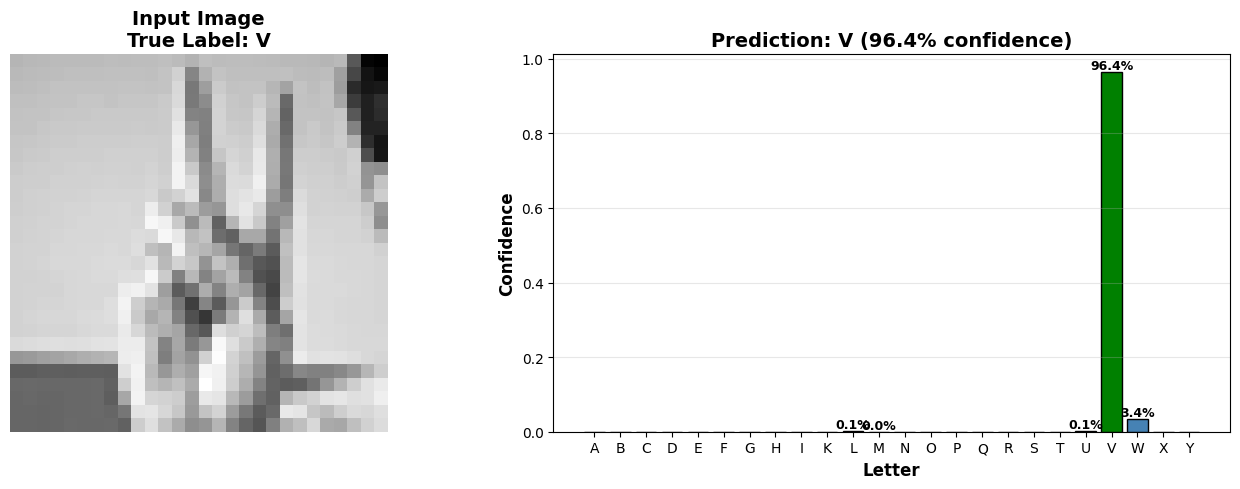